# Set up

## Imports

The following code imports all required libraries for video processing, CNN feature extraction, temporal sequence modelling, and evaluation.

In [ ]:
import numpy as np
import pandas as pd
import cv2
import os
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/jonathannield/cctv-action-recognition-dataset")
od.download("https://www.kaggle.com/datasets/uttejkumarkandagatla/fall-detection-dataset")
od.download("https://www.kaggle.com/datasets/simuletic/cctv-incident-dataset-fall-and-lying-down-detection")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: tarshithbodha
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jonathannield/cctv-action-recognition-dataset


100%|██████████| 517M/517M [00:27<00:00, 19.7MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: tarshithbodha
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uttejkumarkandagatla/fall-detection-dataset


100%|██████████| 49.7M/49.7M [00:04<00:00, 12.9MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: tarshithbodha
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/simuletic/cctv-incident-dataset-fall-and-lying-down-detection


100%|██████████| 162M/162M [00:09<00:00, 17.5MB/s]


## Dataset Paths

The following code defines the Dataset 1 and Dataset 3 paths.

In [ ]:
DATASET_1 = Path(
    "/content/fall-detection-dataset/fall_dataset"
)

DATASET_3 = Path(
    "/content/cctv-action-recognition-dataset"
)

print(DATASET_1.exists())
print(DATASET_3.exists())

True
True


# Build Dataset 3 Video Manifest

The following code scans Dataset 3 and creates a dataframe containing video paths and binary labels

In [ ]:
video_rows = []

# IMPORTANT:
# ONLY actual falls
fall_actions = ["fall"]

# Non-fall actions
non_fall_actions = [
    "walk",
    "stand",
    "run",
    "sit"
]

video_root = (
    DATASET_3 /
    "Videos" /
    "Videos"
)

for action_dir in video_root.iterdir():

    if not action_dir.is_dir():
        continue

    action = action_dir.name

    # Skip unwanted actions
    if (
        action not in fall_actions
        and action not in non_fall_actions
    ):
        continue

    if action in fall_actions:
        label = 1
        binary_name = "fall"
    else:
        label = 0
        binary_name = "not_fallen"

    for video_path in action_dir.glob("*.mp4"):

        video_rows.append({

            "video_path": str(video_path),

            "video_name": video_path.name,

            "action": action,

            "binary_label": label,

            "binary_name": binary_name

        })

df_videos = pd.DataFrame(video_rows)

print(df_videos.head())

print("\nDataset shape:")
print(df_videos.shape)

print("\nBinary distribution:")
print(
    df_videos["binary_name"]
    .value_counts()
)

                                          video_path  \
0  /content/cctv-action-recognition-dataset/Video...   
1  /content/cctv-action-recognition-dataset/Video...   
2  /content/cctv-action-recognition-dataset/Video...   
3  /content/cctv-action-recognition-dataset/Video...   
4  /content/cctv-action-recognition-dataset/Video...   

                         video_name action  binary_label binary_name  
0  YOUTUBE_YouTubeCCTV002_run_3.mp4    run             0  not_fallen  
1           NTU_fight0210_run_1.mp4    run             0  not_fallen  
2          SPHAR_p08faint_run_1.mp4    run             0  not_fallen  
3    UCFCRIME_Burglary033_run_1.mp4    run             0  not_fallen  
4  YOUTUBE_YouTubeCCTV004_run_7.mp4    run             0  not_fallen  

Dataset shape:
(1000, 5)

Binary distribution:
binary_name
not_fallen    800
fall          200
Name: count, dtype: int64


## Train/Validation split

The following code performs video-level train/validation splitting to prevent temporal leakage between training and validation sequences.

In [ ]:
from sklearn.model_selection import train_test_split

train_videos, val_videos = train_test_split(

    df_videos,

    test_size=0.2,

    stratify=df_videos["binary_label"],

    random_state=42

)

print("Train videos:")
print(train_videos.shape)

print("\nValidation videos:")
print(val_videos.shape)

print("\nTrain distribution:")
print(
    train_videos["binary_name"]
    .value_counts()
)

print("\nValidation distribution:")
print(
    val_videos["binary_name"]
    .value_counts()
)

Train videos:
(800, 5)

Validation videos:
(200, 5)

Train distribution:
binary_name
not_fallen    640
fall          160
Name: count, dtype: int64

Validation distribution:
binary_name
not_fallen    160
fall           40
Name: count, dtype: int64


The following code samples a diverse subset of videos to improve environmental and motion diversity during temporal training.

In [ ]:
small_train_videos = (
    train_videos.groupby("binary_name")
    .sample(n=160, random_state=42)
)

# Use ALL validation videos
small_val_videos = val_videos.copy()

print("\nSmall train videos:")
print(
    small_train_videos["binary_name"]
    .value_counts()
)

print("\nValidation videos:")
print(
    small_val_videos["binary_name"]
    .value_counts()
)


Small train videos:
binary_name
fall          160
not_fallen    160
Name: count, dtype: int64

Validation videos:
binary_name
not_fallen    160
fall           40
Name: count, dtype: int64


The following code extracts ordered temporal frame sequences while reducing temporal label noise in fall videos.

In [ ]:
import cv2
import numpy as np

SEQUENCE_LENGTH = 5
IMG_SIZE = 224

def extract_video_sequences(
    video_df,
    sequence_length=5,
    img_size=224
):

    sequences = []
    labels = []

    for _, row in video_df.iterrows():

        video_path = row["video_path"]
        label = row["binary_label"]

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        if total_frames < sequence_length:

            cap.release()
            continue

        # -----------------------------
        # FALL VIDEOS
        # Sample ONLY final 20%
        # -----------------------------
        if label == 1:

            start_frame = int(
                total_frames * 0.8
            )

            frame_indices = np.linspace(

                start_frame,

                total_frames - 1,

                sequence_length,

                dtype=int

            )

        # -----------------------------
        # NON-FALL VIDEOS
        # Sample entire clip
        # -----------------------------
        else:

            frame_indices = np.linspace(

                0,

                total_frames - 1,

                sequence_length,

                dtype=int

            )

        sequence = []

        for idx in frame_indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                idx
            )

            ret, frame = cap.read()

            if not ret:
                continue

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frame = cv2.resize(
                frame,
                (img_size, img_size)
            )

            frame = frame.astype(
                "float32"
            ) / 255.0

            sequence.append(frame)

        cap.release()

        if len(sequence) == sequence_length:

            sequences.append(sequence)
            labels.append(label)

    return (
        np.array(sequences),
        np.array(labels)
    )

The following code converts CCTV videos into ordered temporal frame sequences for CNN+LSTM training.

In [ ]:
X_train_seq, y_train_seq = extract_video_sequences(
    small_train_videos
)

X_val_seq, y_val_seq = extract_video_sequences(
    small_val_videos
)

print("\nTraining sequence shape:")
print(X_train_seq.shape)

print("\nTraining labels shape:")
print(y_train_seq.shape)

print("\nValidation sequence shape:")
print(X_val_seq.shape)

print("\nValidation labels shape:")
print(y_val_seq.shape)

print("\nTraining label counts:")
print(
    np.bincount(
        y_train_seq.astype(int)
    )
)

print("\nValidation label counts:")
print(
    np.bincount(
        y_val_seq.astype(int)
    )
)


Training sequence shape:
(320, 5, 224, 224, 3)

Training labels shape:
(320,)

Validation sequence shape:
(200, 5, 224, 224, 3)

Validation labels shape:
(200,)

Training label counts:
[160 160]

Validation label counts:
[160  40]


The following code creates a lightweight augmentation pipeline suitable for temporal CCTV modelling.

In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.03
    ),

    layers.RandomZoom(
        0.08
    ),

    layers.RandomContrast(
        0.10
    )

])

# BUILDING CNN + LTSM Model

The following code builds a temporal CNN+LSTM architecture using MobileNetV2 feature extraction and sequence learning.

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# -----------------------------
# CNN backbone
# -----------------------------
cnn_base = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224, 224, 3)

)

cnn_base.trainable = False

# -----------------------------
# Frame feature extractor
# -----------------------------
frame_inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(frame_inputs)

x = cnn_base(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

frame_feature_extractor = tf.keras.Model(
    frame_inputs,
    x
)

# -----------------------------
# Sequence model
# -----------------------------
sequence_input = tf.keras.Input(

    shape=(
        SEQUENCE_LENGTH,
        224,
        224,
        3
    )

)

x = layers.TimeDistributed(
    frame_feature_extractor
)(sequence_input)

x = layers.LSTM(
    128,
    return_sequences=False
)(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model_lstm = tf.keras.Model(
    sequence_input,
    outputs
)

model_lstm.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 5, 224, 224, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 1280)        │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,713 (11.40 MB)

 Trainable params: 729,729 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

The following code compiles the CNN+LSTM temporal fall-detection model.

In [ ]:
model_lstm.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )

    ]
)

The following code creates callbacks for early stopping and adaptive learning-rate scheduling during temporal model training.

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-6,

    verbose=1
)

## FIRST TRAIN

The following code trains the CNN+LSTM temporal fall-detection model using ordered CCTV frame sequences.

In [ ]:
history_lstm = model_lstm.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=12,

    batch_size=8,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.5688 - loss: 0.7021 - precision: 0.5679 - recall: 0.5750 - val_accuracy: 0.3050 - val_loss: 0.7648 - val_precision: 0.1847 - val_recall: 0.7250 - learning_rate: 1.0000e-04
Epoch 2/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.6531 - loss: 0.6467 - precision: 0.6416 - recall: 0.6938 - val_accuracy: 0.5200 - val_loss: 0.7010 - val_precision: 0.2143 - val_recall: 0.5250 - learning_rate: 1.0000e-04
Epoch 3/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.6781 - loss: 0.6177 - precision: 0.6748 - recall: 0.6875 - val_accuracy: 0.5400 - val_loss: 0.7134 - val_precision: 0.2451 - val_recall: 0.6250 - learning_rate: 1.0000e-04
Epoch 4/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7185 - loss: 0.5963 - precision: 0.7763 - recall: 0.6288
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
40/40 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.7281 - loss: 0.5939 - precision: 0.7744

## Checkpoint 1 — Save After Training


In [ ]:
# ── CHECKPOINT 1: Save after first training ──────────────────
# Run this immediately after training finishes!
model_lstm.save("model_checkpoint1.h5")
print("Checkpoint 1 saved — model_checkpoint1.h5")

# Also save to Google Drive for backup
from google.colab import drive
import os
drive.mount("/content/drive", force_remount=False)
os.makedirs("/content/drive/MyDrive/fallguard", exist_ok=True)
model_lstm.save("/content/drive/MyDrive/fallguard/model_checkpoint1.h5")
print("Checkpoint 1 also backed up to Google Drive!")


Checkpoint 1 saved — model_checkpoint1.h5
Mounted at /content/drive


Checkpoint 1 also backed up to Google Drive!


## Threshold-tuning

The following code evaluates threshold-dependent CNN+LSTM performance across multiple operating points.

In [ ]:
# Predict probabilities
y_prob_lstm = model_lstm.predict(
    X_val_seq
).ravel()

thresholds = [
    0.5,
    0.4,
    0.35,
    0.3,
    0.25
]

for threshold in thresholds:

    print(f"\n=== Threshold = {threshold} ===")

    y_pred_thresh = (
        y_prob_lstm >= threshold
    ).astype(int)

    print("\nConfusion matrix:")
    print(
        confusion_matrix(
            y_val_seq,
            y_pred_thresh
        )
    )

    print("\nClassification report:")
    print(
        classification_report(

            y_val_seq,

            y_pred_thresh,

            target_names=[
                "not_fallen",
                "fall"
            ],

            digits=4

        )
    )

7/7 ━━━━━━━━━━━━━━━━━━━━ 62s 8s/step

=== Threshold = 0.5 ===

Confusion matrix:
[[83 77]
 [19 21]]

Classification report:
              precision    recall  f1-score   support

  not_fallen     0.8137    0.5188    0.6336       160
        fall     0.2143    0.5250    0.3043        40

    accuracy                         0.5200       200
   macro avg     0.5140    0.5219    0.4690       200
weighted avg     0.6938    0.5200    0.5677       200


=== Threshold = 0.4 ===

Confusion matrix:
[[ 19 141]
 [  5  35]]

Classification report:
              precision    recall  f1-score   support

  not_fallen     0.7917    0.1187    0.2065       160
        fall     0.1989    0.8750    0.3241        40

    accuracy                         0.2700       200
   macro avg     0.4953    0.4969    0.2653       200
weighted avg     0.6731    0.2700    0.2300       200


=== Threshold = 0.35 ===

Confusion matrix:
[[  2 158]
 [  2  38]]

Classification report:
              precision    recall  f1-s

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

## Checkpoint 2 — Save After Threshold Tuning


In [ ]:
# ── CHECKPOINT 2: Save after threshold tuning ────────────────
# Now you know the best threshold — save that info too!
import json

best_threshold = 0.5   # <-- change this to whichever threshold gave best results above

model_lstm.save("model_final.h5")

# Save threshold info so you never forget it
with open("model_info.json", "w") as f:
    json.dump({"best_threshold": best_threshold, "sequence_length": 5, "img_size": 224}, f)

print(f"Final model saved as model_final.h5")
print(f"Best threshold: {best_threshold}")
print("model_info.json saved — use this threshold in app.py")


Final model saved as model_final.h5
Best threshold: 0.5
model_info.json saved — use this threshold in app.py


## OUTPUT of FIRST CNN + LTSM

The following code generates the confusion matrix heatmap for the best-performing CNN+LSTM threshold.

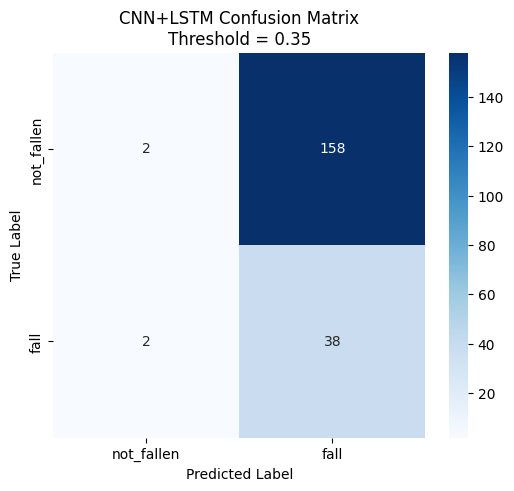

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# -----------------------------
# Best threshold
# -----------------------------
best_threshold = 0.35

# Convert probabilities
y_pred_best = (
    y_prob_lstm >= best_threshold
).astype(int)

# Confusion matrix
cm = confusion_matrix(
    y_val_seq,
    y_pred_best
)

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "not_fallen",
        "fall"
    ],

    yticklabels=[
        "not_fallen",
        "fall"
    ]

)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    f"CNN+LSTM Confusion Matrix\nThreshold = {best_threshold}"
)

plt.show()

## Save Confusion Matrix


In [ ]:
# ── Save confusion matrix plot ───────────────────────────────
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
print("confusion_matrix.png saved!")


confusion_matrix.png saved!


<Figure size 640x480 with 0 Axes>

The following code generates the ROC curve and calculates the CNN+LSTM AUC score.

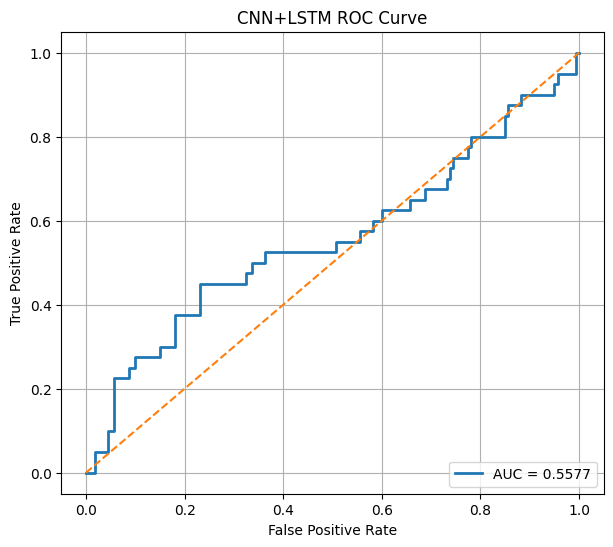


CNN+LSTM AUC Score: 0.5577


In [ ]:
from sklearn.metrics import (
    roc_curve,
    auc
)

# -----------------------------
# ROC computation
# -----------------------------
fpr, tpr, roc_thresholds = roc_curve(
    y_val_seq,
    y_prob_lstm
)

roc_auc = auc(
    fpr,
    tpr
)

# -----------------------------
# Plot ROC
# -----------------------------
plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {roc_auc:.4f}"

)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("CNN+LSTM ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

print(f"\nCNN+LSTM AUC Score: {roc_auc:.4f}")

## Save ROC Curve


In [ ]:
# ── Save ROC curve plot ──────────────────────────────────────
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
print("roc_curve.png saved!")


roc_curve.png saved!


<Figure size 640x480 with 0 Axes>

The following code generates the precision-recall curve for CNN+LSTM fall detection.

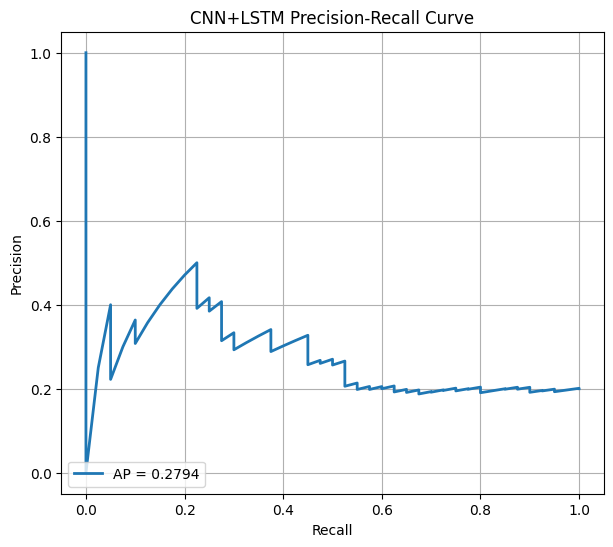


Average Precision Score: 0.2794


In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision, recall, pr_thresholds = (
    precision_recall_curve(
        y_val_seq,
        y_prob_lstm
    )
)

ap_score = average_precision_score(
    y_val_seq,
    y_prob_lstm
)

# -----------------------------
# Plot PR curve
# -----------------------------
plt.figure(figsize=(7,6))

plt.plot(

    recall,

    precision,

    linewidth=2,

    label=f"AP = {ap_score:.4f}"

)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("CNN+LSTM Precision-Recall Curve")

plt.legend(loc="lower left")

plt.grid(True)

plt.show()

print(
    f"\nAverage Precision Score: {ap_score:.4f}"
)

## Save PR Curve


In [ ]:
# ── Save Precision-Recall curve plot ─────────────────────────
plt.savefig("precision_recall_curve.png", dpi=150, bbox_inches="tight")
print("precision_recall_curve.png saved!")


precision_recall_curve.png saved!


<Figure size 640x480 with 0 Axes>

In [ ]:
model_lstm.save("model.h5")
# then download model.h5 from the Colab files panel

## Final Save — Everything to Google Drive
Run this last to back everything up!


In [ ]:
# ── FINAL SAVE: Everything to Google Drive ───────────────────
from google.colab import drive
import shutil, os
drive.mount("/content/drive", force_remount=False)

save_dir = "/content/drive/MyDrive/fallguard"
os.makedirs(save_dir, exist_ok=True)

# Copy all important files to Drive
files_to_save = [
    "model_final.h5",
    "model_info.json",
    "confusion_matrix.png",
    "roc_curve.png",
    "precision_recall_curve.png",
]

for fname in files_to_save:
    if os.path.exists(fname):
        shutil.copy(fname, f"{save_dir}/{fname}")
        print(f"Saved {fname} to Drive")
    else:
        print(f"WARNING: {fname} not found, skipping")

print("All done! Check My Drive > fallguard folder.")
print("Download model_final.h5 and put it in your local project folder.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved model_final.h5 to Drive
Saved model_info.json to Drive
Saved confusion_matrix.png to Drive
Saved roc_curve.png to Drive
Saved precision_recall_curve.png to Drive
All done! Check My Drive > fallguard folder.
Download model_final.h5 and put it in your local project folder.
